In [1]:
%pip install xlrd==2.0.1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings, os, urllib.request

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid', palette='muted')

PALETTE = ['#2176AE','#57B8FF','#B66D0D','#3BB273','#E84855',
           '#7B2D8B','#F4A261','#264653','#E76F51','#2A9D8F']



data_file = Path(r'C:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\Week2\Day5\DailyChallenge\US Superstore data.xls')
if not data_file.exists():
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidate = parent / 'US Superstore Sales.xlsx'
        if candidate.exists():
            data_file = candidate
            break
    else:
        raise FileNotFoundError(
            "Dataset 'US Superstore Sales.xlsx' not found in current or parent directories."
        )

store_raw = pd.read_excel(data_file)
store = store_raw.copy()
print(f"Dimensions brutes : {store.shape[0]:,} lignes x {store.shape[1]} colonnes")
store.head(3)



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dimensions brutes : 9,994 lignes x 21 colonnes


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [2]:
print("Data types :")
print(store.dtypes.to_string())
print()
print("Descriptive Statistics :")
display(store[['Sales','Quantity','Discount','Profit']].describe().round(2))
print()
miss = store.isnull().sum()
print("Missing Values :")
print(miss[miss > 0] if miss.sum() > 0 else "  No missing values")


Data types :
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64

Descriptive Statistics :


,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98



Missing Values :
  No missing values


In [3]:
# --- Variables derivees ---
store['Order Date'] = pd.to_datetime(store['Order Date'])
store['Ship Date']  = pd.to_datetime(store['Ship Date'])
store['Year']        = store['Order Date'].dt.year
store['Month']       = store['Order Date'].dt.month
store['YearMonth']   = store['Order Date'].dt.to_period('M')
store['Ship_Delay']  = (store['Ship Date'] - store['Order Date']).dt.days
store['Profit_Margin'] = (store['Profit'] / store['Sales'].replace(0, np.nan) * 100).round(2)

# --- Doublons ---
nb_dup = store.duplicated().sum()
store = store.drop_duplicates()
store['Postal Code'] = store['Postal Code'].astype(str).str.zfill(5)

print("Nettoyage termine")
print(f"  Doublons supprimes        : {nb_dup}")
print(f"  Dimensions finales        : {store.shape[0]:,} lignes x {store.shape[1]} colonnes")
print(f"  Periode                   : {store['Year'].min()} - {store['Year'].max()}")
print(f"  Delai moyen d expedition  : {store['Ship_Delay'].mean():.1f} jours")
print(f"  Ventes totales            : ${store['Sales'].sum():,.0f}")
print(f"  Profit total              : ${store['Profit'].sum():,.0f}")
print(f"  Marge moyenne             : {store['Profit_Margin'].mean():.1f}%")


Nettoyage termine
  Doublons supprimes        : 0
  Dimensions finales        : 9,994 lignes x 26 colonnes
  Periode                   : 2014 - 2017
  Delai moyen d expedition  : 4.0 jours
  Ventes totales            : $2,297,201
  Profit total              : $286,397
  Marge moyenne             : 12.0%


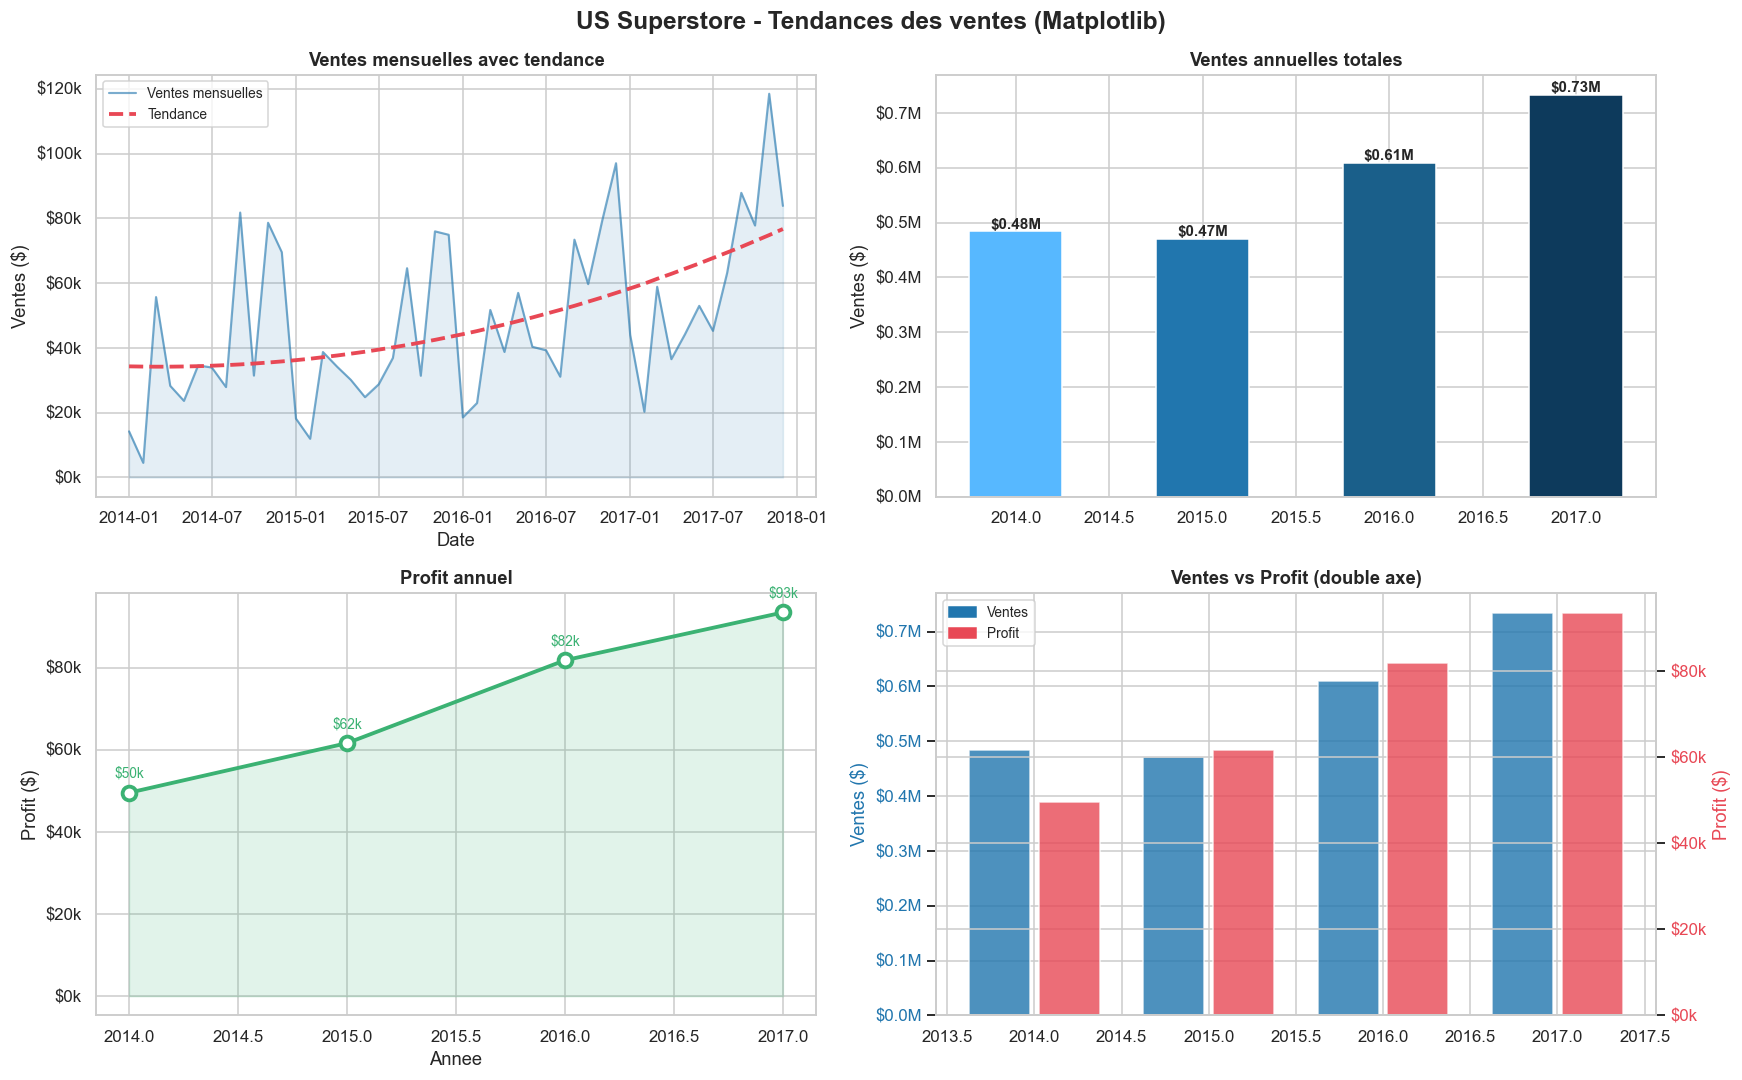

Graphique sauvegarde.


In [4]:
# --- Agregation ---
monthly  = store.groupby('YearMonth')['Sales'].sum().reset_index()
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()
annual = store.groupby('Year').agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum'),
    Orders = ('Order ID', 'nunique')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("US Superstore - Tendances des ventes (Matplotlib)",
             fontsize=16, fontweight='bold')

# 1 - Ventes mensuelles avec tendance
ax1 = axes[0, 0]
ax1.plot(monthly['YearMonth_dt'], monthly['Sales'],
         color='#2176AE', linewidth=1.4, alpha=0.6, label='Ventes mensuelles')
x_num = np.arange(len(monthly))
coefs = np.polyfit(x_num, monthly['Sales'], 2)
trend = np.polyval(coefs, x_num)
ax1.plot(monthly['YearMonth_dt'], trend, color='#E84855', linewidth=2.5,
         linestyle='--', label='Tendance')
ax1.fill_between(monthly['YearMonth_dt'], monthly['Sales'], alpha=0.12, color='#2176AE')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax1.set_title('Ventes mensuelles avec tendance', fontweight='bold')
ax1.set_xlabel('Date'); ax1.set_ylabel('Ventes ($)'); ax1.legend(fontsize=9)

# 2 - Ventes annuelles (barres)
ax2 = axes[0, 1]
bars = ax2.bar(annual['Year'], annual['Sales'],
               color=['#57B8FF','#2176AE','#1A5F8A','#0D3A5C'],
               edgecolor='white', width=0.5)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax2.set_title('Ventes annuelles totales', fontweight='bold'); ax2.set_ylabel('Ventes ($)')
for bar, val in zip(bars, annual['Sales']):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 5000,
             f'${val/1e6:.2f}M', ha='center', fontsize=10, fontweight='bold')

# 3 - Profit annuel
ax3 = axes[1, 0]
ax3.plot(annual['Year'], annual['Profit'], 'o-', color='#3BB273', linewidth=2.5,
         markersize=9, markerfacecolor='white', markeredgewidth=2.5)
ax3.fill_between(annual['Year'], annual['Profit'], alpha=0.15, color='#3BB273')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax3.set_title('Profit annuel', fontweight='bold')
ax3.set_xlabel('Annee'); ax3.set_ylabel('Profit ($)')
for yr, pf in zip(annual['Year'], annual['Profit']):
    ax3.annotate(f'${pf/1000:.0f}k', (yr, pf),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, color='#3BB273')

# 4 - Ventes vs Profit (double axe)
ax4 = axes[1, 1]
ax4.bar(annual['Year'] - 0.2, annual['Sales'], width=0.35,
        color='#2176AE', alpha=0.8, label='Ventes')
ax4.set_ylabel('Ventes ($)', color='#2176AE')
ax4.tick_params(axis='y', labelcolor='#2176AE')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax4b = ax4.twinx()
ax4b.bar(annual['Year'] + 0.2, annual['Profit'], width=0.35,
         color='#E84855', alpha=0.8, label='Profit')
ax4b.set_ylabel('Profit ($)', color='#E84855')
ax4b.tick_params(axis='y', labelcolor='#E84855')
ax4b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax4.set_title('Ventes vs Profit (double axe)', fontweight='bold')
p1 = mpatches.Patch(color='#2176AE', label='Ventes')
p2 = mpatches.Patch(color='#E84855', label='Profit')
ax4.legend(handles=[p1, p2], loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('fig_matplotlib_trends.png', dpi=130, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde.")


In [5]:

try:
    import plotly.express as px
    import plotly.io as pio
    # use a renderer that does not require nbformat
    pio.renderers.default = 'browser'

    state_sales = store.groupby('State').agg(
        Sales  = ('Sales',  'sum'),
        Profit = ('Profit', 'sum'),
        Orders = ('Order ID','nunique')
    ).reset_index()
    state_sales['Profit_Rate'] = (state_sales['Profit'] / state_sales['Sales'] * 100).round(1)

    state_abbrev = {
        'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
        'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
        'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA',
        'Kansas':'KS','Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
        'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
        'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH',
        'New Jersey':'NJ','New Mexico':'NM','New York':'NY','North Carolina':'NC',
        'North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA',
        'Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD','Tennessee':'TN',
        'Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
        'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY',
        'District of Columbia':'DC'
    }
    state_sales['Code'] = state_sales['State'].map(state_abbrev)

    fig_map = px.choropleth(
        state_sales, locations='Code', locationmode='USA-states',
        color='Sales', scope='usa', hover_name='State',
        hover_data={'Code': False, 'Sales': ':,.0f', 'Profit': ':,.0f',
                    'Profit_Rate': ':.1f', 'Orders': True},
        color_continuous_scale='Blues',
        title='Repartition of sales by state (US Superstore 2014-2017)',
        labels={'Sales': 'Ventes ($)', 'Profit_Rate': 'Taux profit (%)'}
    )
    fig_map.update_layout(
        geo=dict(showlakes=True, lakecolor='lightblue'),
        coloraxis_colorbar=dict(title='Ventes ($)', tickformat='$,.0f'),
        height=520, margin=dict(l=0, r=0, t=50, b=0)
    )
    fig_map.show()

    print("Top 5 of states by sales :")
    top5 = state_sales.nlargest(5, 'Sales')[['State','Sales','Profit','Profit_Rate']]
    print(top5.to_string(index=False))
except (ImportError, ValueError):
    # Fallback Matplotlib
    state_sales = store.groupby('State')['Sales'].sum().nlargest(20).reset_index()
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.barh(state_sales['State'], state_sales['Sales'],
            color=plt.cm.Blues(np.linspace(0.4, 0.9, len(state_sales))), edgecolor='white')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.set_title('Top 20 States by Sales (fallback Matplotlib)', fontweight='bold')
    ax.set_xlabel('Ventes ($)')
    plt.tight_layout(); plt.show()


Top 5 Etats par ventes :
       State       Sales      Profit  Profit_Rate
  California 457687.6315  76381.3871         16.7
    New York 310876.2710  74038.5486         23.8
       Texas 170188.0458 -25729.3563        -15.1
  Washington 138641.2700  33402.6517         24.1
Pennsylvania 116511.9140 -15559.9603        -13.4


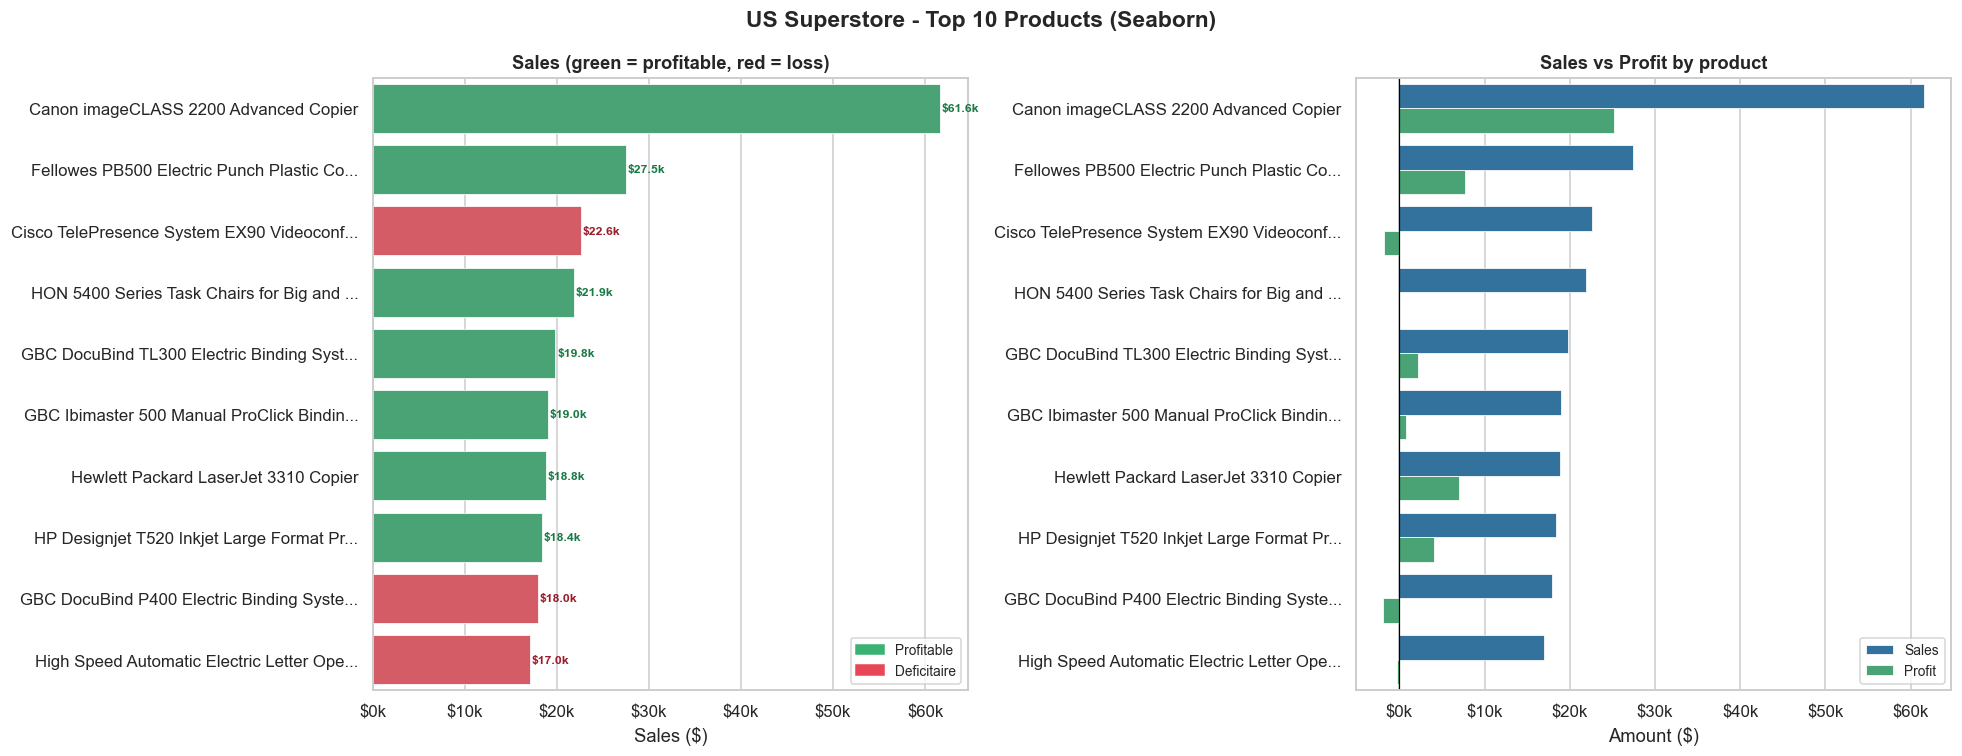

Top 10 of products :


,Product,Sales ($),Profit ($),Quantity,Profitable
0,Canon imageCLASS 2200 Advanced Copier,"$61,600","$25,200",20,True
1,Fellowes PB500 Electric Punch Plastic Co...,"$27,453","$7,753",31,True
2,Cisco TelePresence System EX90 Videoconf...,"$22,638","$-1,811",6,False
3,HON 5400 Series Task Chairs for Big and ...,"$21,871",$0,39,True
4,GBC DocuBind TL300 Electric Binding Syst...,"$19,823","$2,234",37,True
5,GBC Ibimaster 500 Manual ProClick Bindin...,"$19,024",$761,48,True
6,Hewlett Packard LaserJet 3310 Copier,"$18,840","$6,984",38,True
7,HP Designjet T520 Inkjet Large Format Pr...,"$18,375","$4,095",12,True
8,GBC DocuBind P400 Electric Binding Syste...,"$17,965","$-1,878",27,False
9,High Speed Automatic Electric Letter Ope...,"$17,030",$-262,11,False


In [8]:
# --- Top 10 produits ---
df = store.copy()

top10 = (df.groupby('Product Name')
           .agg(Sales=('Sales','sum'), Profit=('Profit','sum'), Qty=('Quantity','sum'))
           .nlargest(10, 'Sales')
           .reset_index())
top10['Short'] = top10['Product Name'].apply(lambda x: x[:40] + '...' if len(x) > 40 else x)
top10['Profitable'] = top10['Profit'] > 0

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("US Superstore - Top 10 Products (Seaborn)", fontsize=15, fontweight='bold')

# Palette par rentabilite
pal = ['#3BB273' if p else '#E84855' for p in top10['Profitable']]

# 1 - Barres horizontales
ax1 = axes[0]
sns.barplot(data=top10, y='Short', x='Sales', palette=pal, ax=ax1,
            edgecolor='white', linewidth=0.5, orient='h', hue='Short', legend=False)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax1.set_title('Sales (green = profitable, red = loss)', fontweight='bold')
ax1.set_xlabel('Sales ($)'); ax1.set_ylabel('')
for i, (_, row) in enumerate(top10.iterrows()):
    c = '#1A7A45' if row['Profitable'] else '#9B1C2A'
    ax1.text(row['Sales'] + 200, i, f"${row['Sales']/1000:.1f}k",
             va='center', fontsize=8, color=c, fontweight='bold')
gp = mpatches.Patch(color='#3BB273', label='Profitable')
rp = mpatches.Patch(color='#E84855', label='Deficitaire')
ax1.legend(handles=[gp, rp], loc='lower right', fontsize=9)

# 2 - Sales vs Profit (grouped bars)
melt = top10[['Short','Sales','Profit']].melt(id_vars='Short', var_name='Metrique', value_name='Valeur')
ax2 = axes[1]
sns.barplot(data=melt, y='Short', x='Valeur', hue='Metrique', ax=ax2, orient='h',
            palette={'Sales': '#2176AE', 'Profit': '#3BB273'}, edgecolor='white', linewidth=0.5)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Sales vs Profit by product', fontweight='bold')
ax2.set_xlabel('Amount ($)'); ax2.set_ylabel('')
ax2.legend(title='', fontsize=9)

plt.tight_layout()
plt.savefig('fig_seaborn_top10.png', dpi=130, bbox_inches='tight')
plt.show()

print("Top 10 of products :")
top10_display = top10[['Short','Sales','Profit','Qty','Profitable']].rename(
    columns={'Short':'Product','Sales':'Sales ($)','Profit':'Profit ($)',
             'Qty':'Quantity','Profitable':'Profitable'}
)
top10_display['Sales ($)'] = top10_display['Sales ($)'].map('${:,.0f}'.format)
top10_display['Profit ($)'] = top10_display['Profit ($)'].map('${:,.0f}'.format)
display(top10_display)


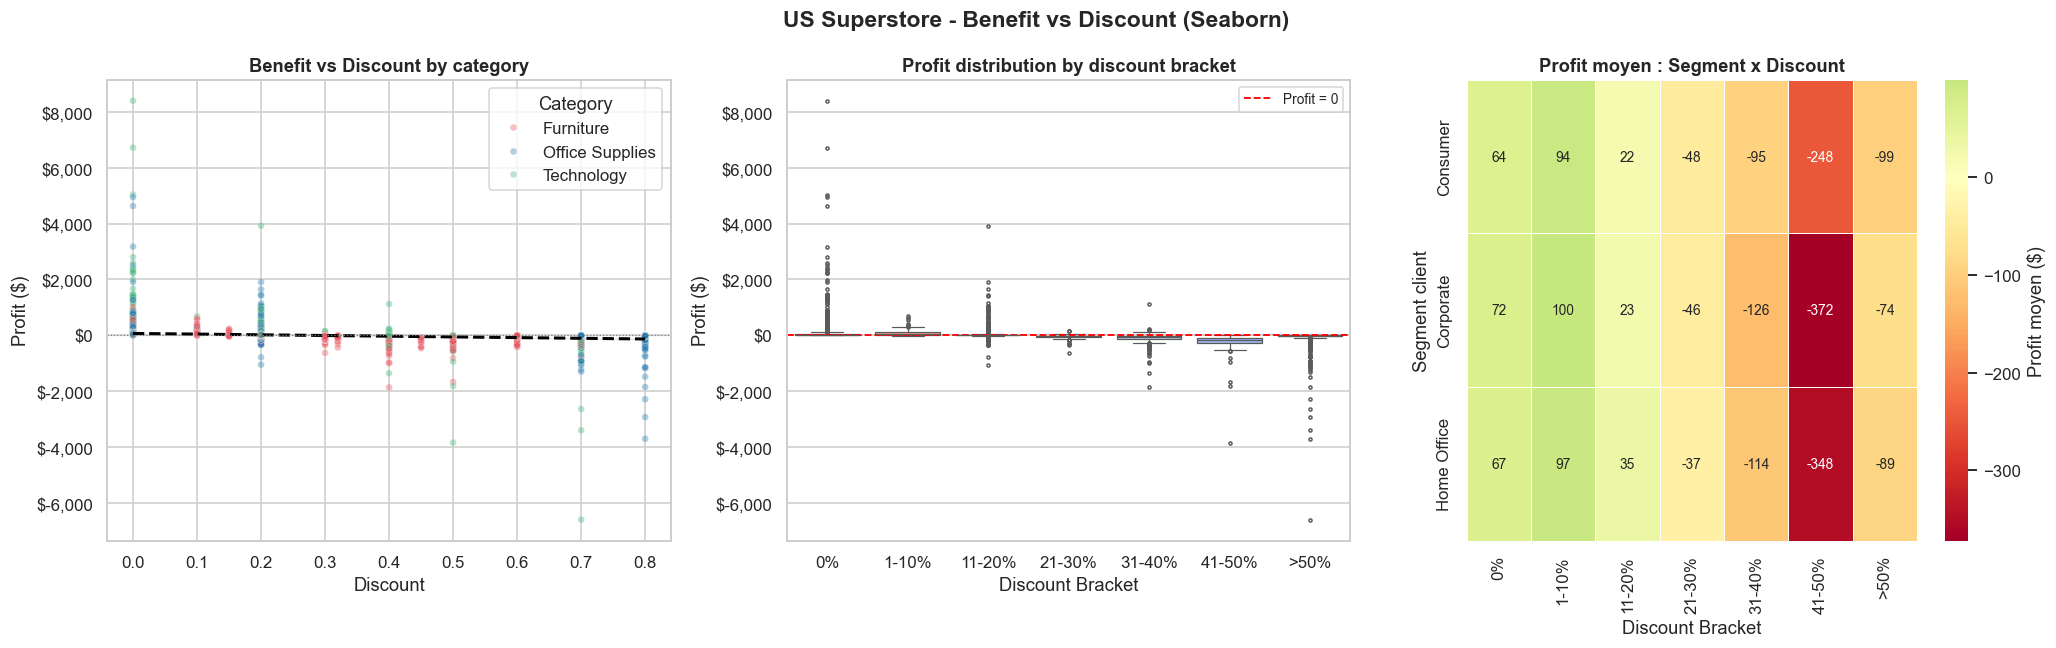

Discount-Profit Correlation : -0.2195
       0%  ->  $      67
    1-10%  ->  $      96
   11-20%  ->  $      25
   21-30%  ->  $     -46
   31-40%  ->  $    -109
   41-50%  ->  $    -299
     >50%  ->  $     -89


In [10]:
# --- Profit vs Remise ---
cat_palette = {'Furniture':'#E84855','Office Supplies':'#2176AE','Technology':'#3BB273'}

df['Discount_Bin'] = pd.cut(df['Discount'],
                            bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.40, 0.50, 1.0],
                            labels=['0%','1-10%','11-20%','21-30%','31-40%','41-50%','>50%'])

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle("US Superstore - Benefit vs Discount (Seaborn)", fontsize=15, fontweight='bold')

# 1 - Scatter + regression globale
ax1 = axes[0]
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
                palette=cat_palette, alpha=0.35, s=20, ax=ax1)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, ax=ax1,
            line_kws={'color':'black','linewidth':2,'linestyle':'--'})
ax1.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_title('Benefit vs Discount by category', fontweight='bold')
ax1.set_xlabel('Discount'); ax1.set_ylabel('Profit ($)')

# 2 - Boxplot par tranche de remise
order = ['0%','1-10%','11-20%','21-30%','31-40%','41-50%','>50%']
ax2 = axes[1]
sns.boxplot(data=df, x='Discount_Bin', y='Profit', palette='coolwarm_r',
            ax=ax2, order=order, linewidth=0.8, fliersize=2)
ax2.axhline(0, color='red', linewidth=1.2, linestyle='--', label='Profit = 0')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_title('Profit distribution by discount bracket', fontweight='bold')
ax2.set_xlabel('Discount Bracket'); ax2.set_ylabel('Profit ($)')
ax2.legend(fontsize=9)

# 3 - Heatmap segment x remise
pivot = df.groupby(['Segment','Discount_Bin'], observed=True)['Profit'].mean().unstack()
ax3 = axes[2]
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            ax=ax3, linewidths=0.5, annot_kws={'size':9},
            cbar_kws={'label':'Profit moyen ($)'})
ax3.set_title('Profit moyen : Segment x Discount', fontweight='bold')
ax3.set_xlabel('Discount Bracket'); ax3.set_ylabel('Segment client')

plt.tight_layout()
plt.savefig('fig_seaborn_discount.png', dpi=130, bbox_inches='tight')
plt.show()

corr = df['Discount'].corr(df['Profit'])
print(f"Discount-Profit Correlation : {corr:.4f}")
avg = df.groupby('Discount_Bin', observed=True)['Profit'].mean()
for disc, prof in avg.items():
    print(f"  {str(disc):>7}  ->  ${prof:>8,.0f}")


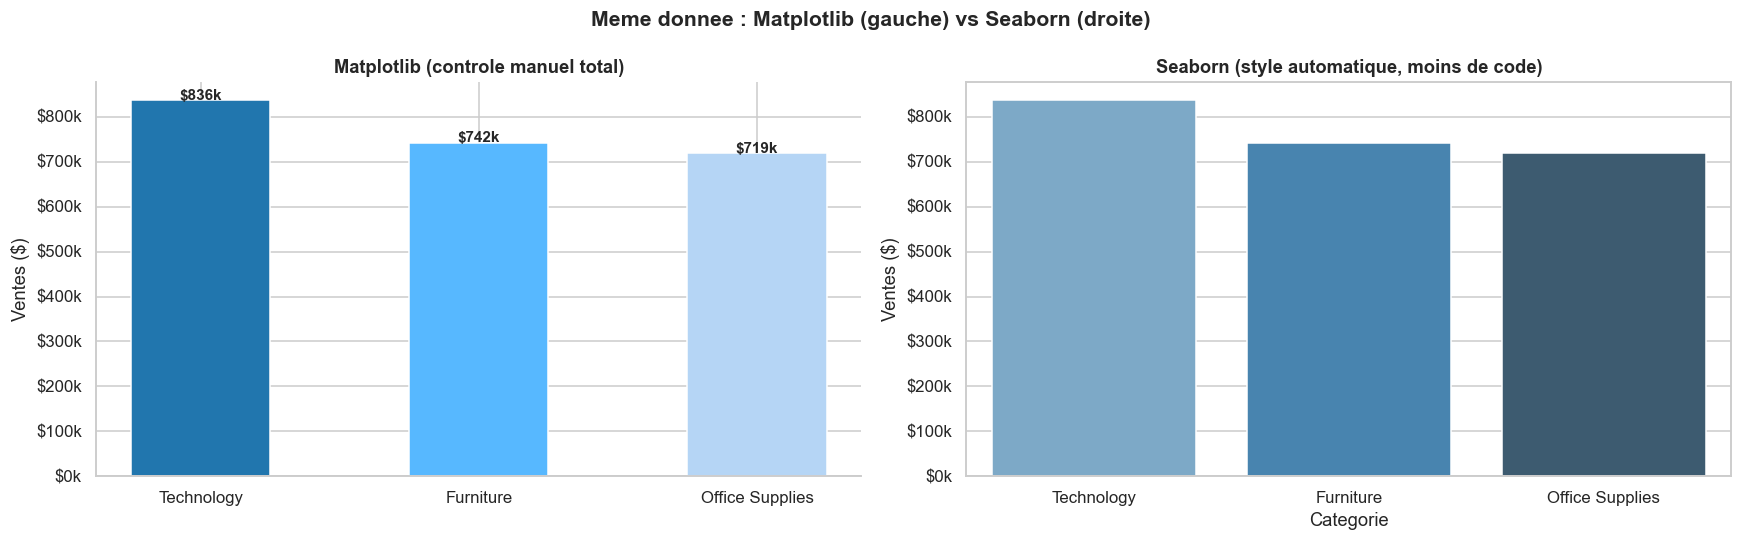

Observation : Seaborn produit un graphique esthetique en 2 lignes.
Matplotlib requiert ~10 lignes mais offre un controle total.


In [11]:
# --- Meme donnee, deux styles ---
cat_data = df.groupby('Category').agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum')
).sort_values('Sales', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Meme donnee : Matplotlib (gauche) vs Seaborn (droite)",
             fontsize=14, fontweight='bold')

# Matplotlib
ax1 = axes[0]
bars = ax1.bar(cat_data['Category'], cat_data['Sales'],
               color=['#2176AE','#57B8FF','#B5D5F5'],
               edgecolor='white', width=0.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax1.set_title('Matplotlib (controle manuel total)', fontweight='bold')
ax1.set_ylabel('Ventes ($)')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
for bar, val in zip(bars, cat_data['Sales']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 1000,
             f'${val/1000:.0f}k', ha='center', fontsize=10, fontweight='bold')

# Seaborn
ax2 = axes[1]
sns.barplot(data=cat_data, x='Category', y='Sales', palette='Blues_d',
            ax=ax2, edgecolor='white', hue='Category', legend=False)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax2.set_title('Seaborn (style automatique, moins de code)', fontweight='bold')
ax2.set_ylabel('Ventes ($)'); ax2.set_xlabel('Categorie')

plt.tight_layout()
plt.show()
print("Observation : Seaborn produit un graphique esthetique en 2 lignes.")
print("Matplotlib requiert ~10 lignes mais offre un controle total.")


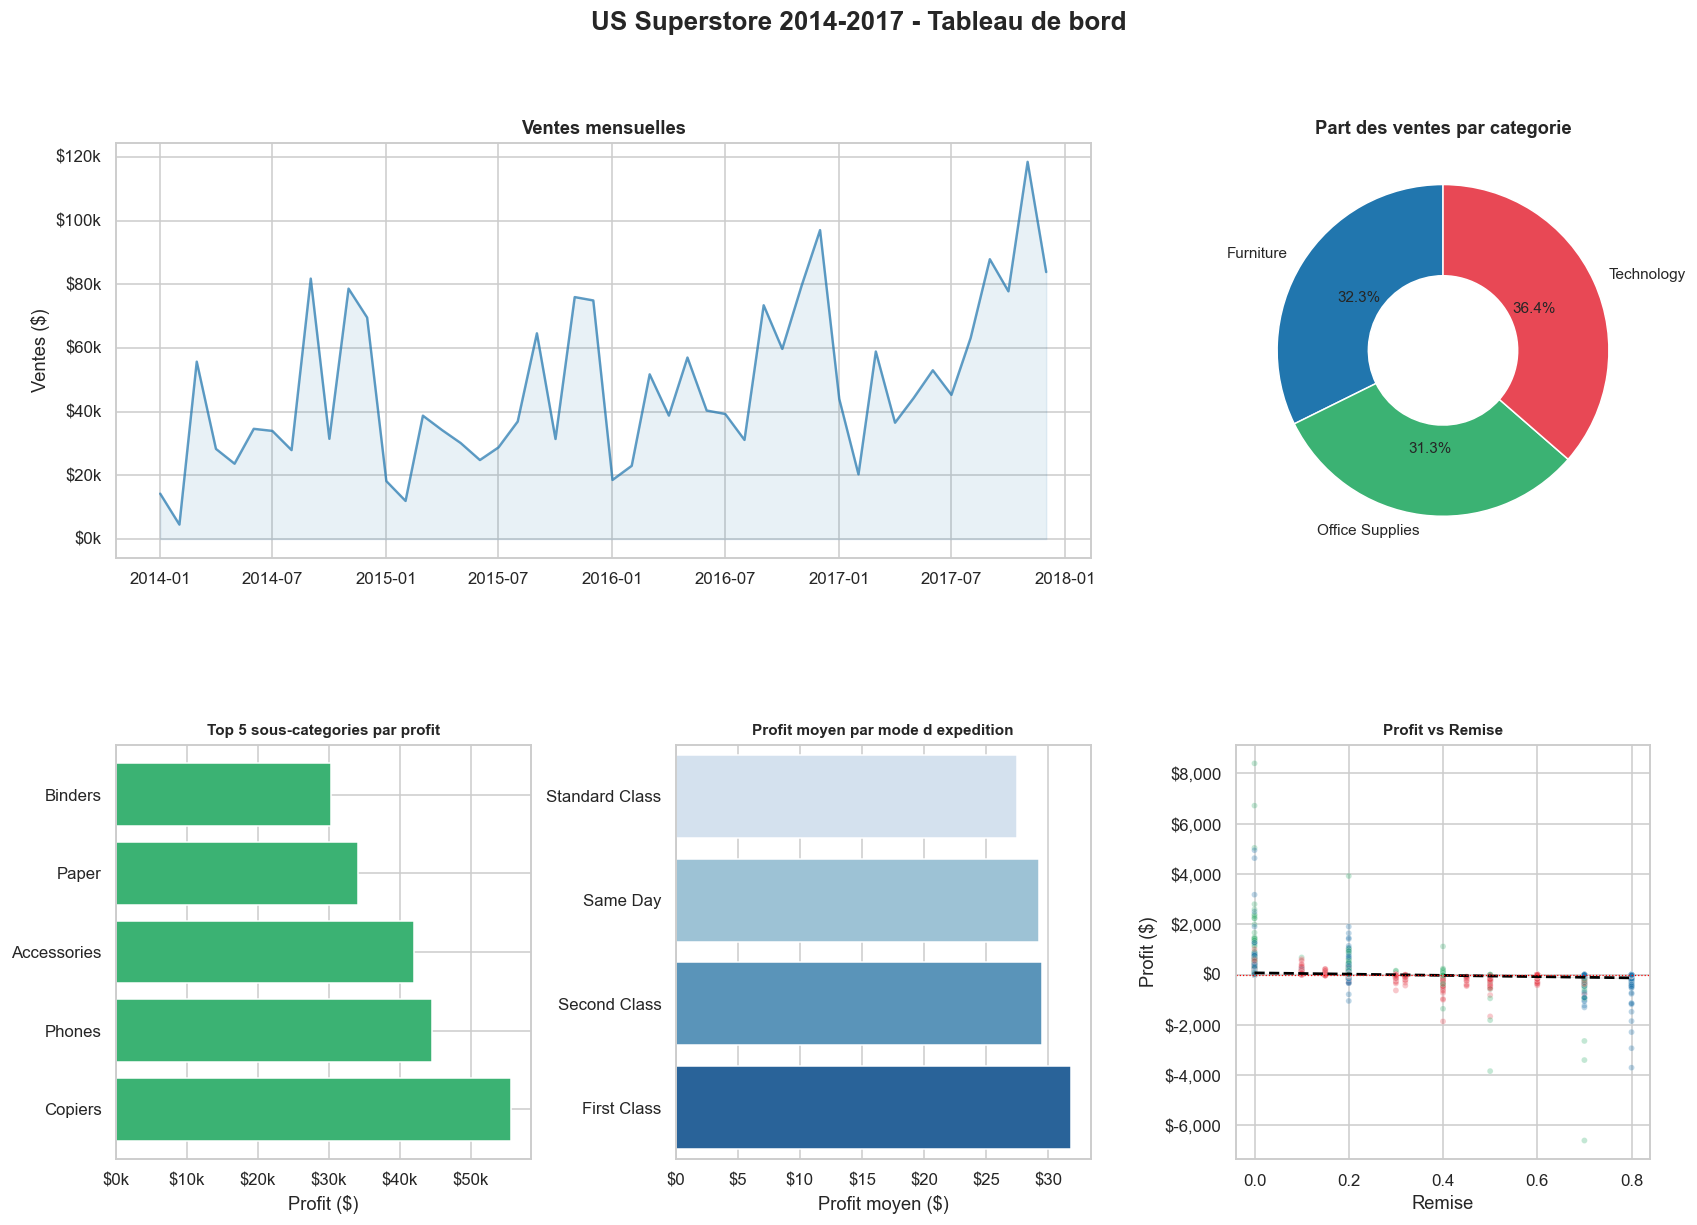

Dashboard sauvegarde.


In [12]:
# --- Dashboard de synthese ---
cat_palette = {'Furniture':'#E84855','Office Supplies':'#2176AE','Technology':'#3BB273'}

fig = plt.figure(figsize=(18, 12))
fig.suptitle("US Superstore 2014-2017 - Tableau de bord",
             fontsize=17, fontweight='bold')
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# 1 - Ventes mensuelles
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(monthly['YearMonth_dt'], monthly['Sales'], color='#2176AE', linewidth=1.6, alpha=0.7)
ax1.fill_between(monthly['YearMonth_dt'], monthly['Sales'], alpha=0.1, color='#2176AE')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax1.set_title('Ventes mensuelles', fontweight='bold')
ax1.set_ylabel('Ventes ($)')

# 2 - Donut categorie
ax2 = fig.add_subplot(gs[0, 2])
cat_s = df.groupby('Category')['Sales'].sum()
ax2.pie(cat_s, labels=cat_s.index, autopct='%1.1f%%',
        colors=['#2176AE','#3BB273','#E84855'],
        wedgeprops=dict(width=0.55), startangle=90, textprops={'fontsize':10})
ax2.set_title('Part des ventes par categorie', fontweight='bold')

# 3 - Top 5 sous-categories par profit
ax3 = fig.add_subplot(gs[1, 0])
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().nlargest(5)
colors_b = ['#3BB273' if v > 0 else '#E84855' for v in subcat_profit]
ax3.barh(subcat_profit.index, subcat_profit.values, color=colors_b, edgecolor='white')
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax3.set_title('Top 5 sous-categories par profit', fontweight='bold', fontsize=10)
ax3.set_xlabel('Profit ($)')

# 4 - Profit par mode d'expedition
ax4 = fig.add_subplot(gs[1, 1])
ship_profit = df.groupby('Ship Mode')['Profit'].mean().sort_values()
sns.barplot(x=ship_profit.values, y=ship_profit.index, palette='Blues', ax=ax4, orient='h')
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax4.set_title("Profit moyen par mode d expedition", fontweight='bold', fontsize=10)
ax4.set_xlabel('Profit moyen ($)'); ax4.set_ylabel('')

# 5 - Scatter Discount vs Profit
ax5 = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
                alpha=0.3, s=15, ax=ax5, palette=cat_palette, legend=False)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, ax=ax5,
            line_kws={'color':'black','linewidth':1.8,'linestyle':'--'})
ax5.axhline(0, color='red', linewidth=0.8, linestyle=':')
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax5.set_title('Profit vs Remise', fontweight='bold', fontsize=10)
ax5.set_xlabel('Remise'); ax5.set_ylabel('Profit ($)')

plt.savefig('fig_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Dashboard sauvegarde.")
